<a href="https://www.kaggle.com/code/gpreda/unemployment-rate-in-europe-grouped-by-countries?scriptVersionId=260317841" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction


Unemployment rate represents unemployed persons as a percentage of the labour force. The labour force is the total number of people employed and unemployed. Unemployed persons comprise persons aged 15 to 74 who were:   
- **a** - without work during the reference week.   
- **b** -  currently available for work, i.e. were available for paid employment or self-employment before the end of the two weeks following the reference week.   
- **c** -  actively seeking work, i.e. had taken specific steps in the four weeks period ending with the reference week to seek paid employment or self-employment or who found a job to start later, i.e. within a period of, at most, three months.   

The indicator is based on the EU Labour Force Survey.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/unemployment-rate-by-sex/estat_tesem120_en.csv")

# Glimpse the data

In [3]:
df.shape

(1728, 11)

In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,DATAFLOW,LAST UPDATE,freq,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2009,5.3,NaN,NaN
1,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2010,4.9,NaN,NaN
2,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2011,4.8,NaN,NaN
3,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2012,5.0,NaN,NaN
4,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2013,5.5,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     1728 non-null   object 
 1   LAST UPDATE  1728 non-null   object 
 2   freq         1728 non-null   object 
 3   age          1728 non-null   object 
 4   unit         1728 non-null   object 
 5   sex          1728 non-null   object 
 6   geo          1728 non-null   object 
 7   TIME_PERIOD  1728 non-null   int64  
 8   OBS_VALUE    1728 non-null   float64
 9   OBS_FLAG     96 non-null     object 
 10  CONF_STATUS  0 non-null      float64
dtypes: float64(2), int64(1), object(8)
memory usage: 148.6+ KB


In [6]:
df.describe()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,TIME_PERIOD,OBS_VALUE,CONF_STATUS
count,1728.000000,1728.000000,0.0
mean,2016.369792,8.955613,NaN
std,4.693298,5.340073,NaN
min,2005.000000,1.700000,NaN
25%,2012.000000,5.400000,NaN
50%,2016.000000,7.500000,NaN
75%,2020.000000,10.700000,NaN
max,2024.000000,32.800000,NaN


In [7]:
df.sex.value_counts()

sex
F    576
M    576
T    576
Name: count, dtype: int64

In [8]:
df.age.value_counts()

age
Y15-74    1728
Name: count, dtype: int64

In [9]:
df.geo.unique()

array(['AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EA20', 'EE',
       'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT',
       'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO',
       'RS', 'SE', 'SI', 'SK', 'TR'], dtype=object)

In [10]:
df.TIME_PERIOD.value_counts()

TIME_PERIOD
2019    108
2011    108
2012    108
2013    108
2014    108
2015    108
2016    108
2017    108
2018    108
2020    108
2024    105
2010    105
2021    105
2022    105
2023    105
2009     99
2005      6
2006      6
2007      6
2008      6
Name: count, dtype: int64

# Cleaning and configs

In [11]:
df = df.replace([np.inf, -np.inf], np.nan)

In [12]:
import warnings
warnings.filterwarnings("ignore")

# Data exploration

Let's show the countries names in full.

In [13]:
europe_countries = {
    "AL": "Albania",
    "AD": "Andorra",
    "AM": "Armenia",
    "AT": "Austria",
    "AZ": "Azerbaijan",
    "BY": "Belarus",
    "BE": "Belgium",
    "BA": "Bosnia and Herzegovina",
    "BG": "Bulgaria",
    "HR": "Croatia",
    "CY": "Cyprus",
    "CZ": "Czechia",
    "DK": "Denmark",
    "EE": "Estonia",
    "FI": "Finland",
    "FR": "France",
    "GE": "Georgia",
    "DE": "Germany",
    "GR": "Greece",
    "HU": "Hungary",
    "IS": "Iceland",
    "IE": "Ireland",
    "IT": "Italy",
    "KZ": "Kazakhstan (partly in Europe)",
    "XK": "Kosovo",
    "LV": "Latvia",
    "LI": "Liechtenstein",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "MT": "Malta",
    "MD": "Moldova",
    "MC": "Monaco",
    "ME": "Montenegro",
    "NL": "Netherlands",
    "MK": "North Macedonia",
    "NO": "Norway",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "RU": "Russia (partly in Europe)",
    "SM": "San Marino",
    "RS": "Serbia",
    "SK": "Slovakia",
    "SI": "Slovenia",
    "ES": "Spain",
    "SE": "Sweden",
    "CH": "Switzerland",
    "TR": "Türkiye (partly in Europe)",
    "UA": "Ukraine",
    "GB": "United Kingdom",
    "VA": "Vatican City"
}
 

We map the country names on `geo` and we just replace with `geo` where there is no mapped value.

In [14]:
df["country_name"] = df["geo"].map(europe_countries)
df.loc[df.country_name.isna(), "country_name"] = df["geo"]

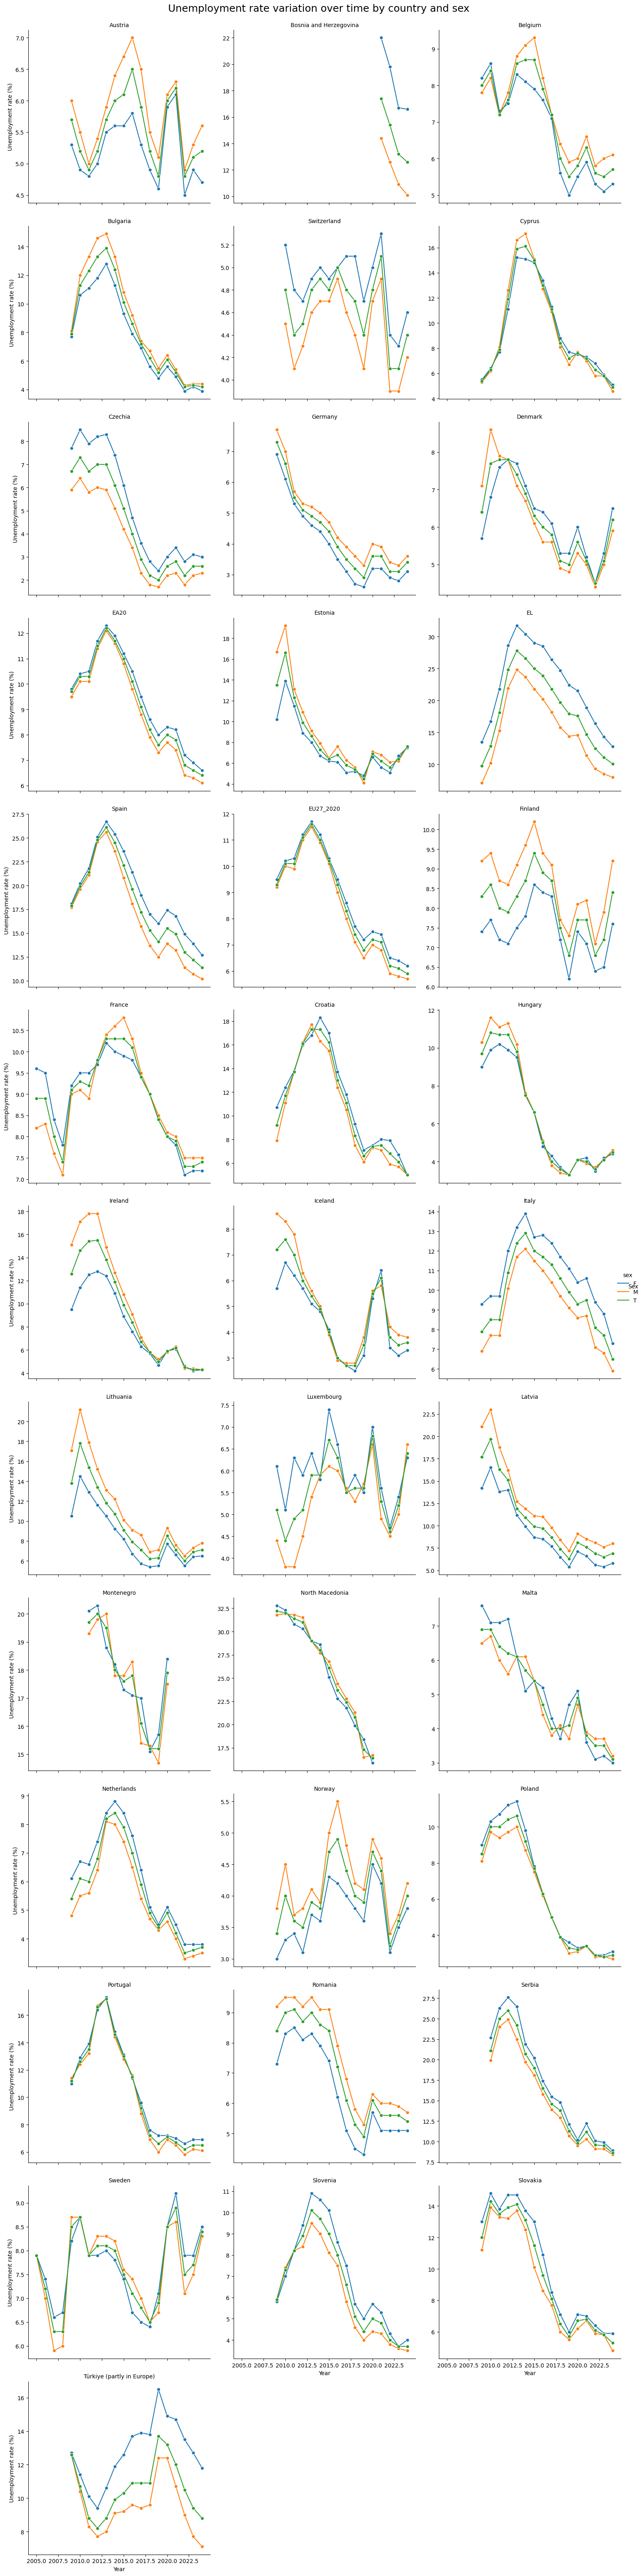

In [15]:
g = sns.relplot(
    data=df,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="sex", kind="line", marker="o",
    col="country_name", col_wrap=3,  # 3 plots per row
    facet_kws={"sharey": False}
)
g.set_axis_labels("Year", "Unemployment rate (%)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.97)
g.fig.suptitle("Unemployment rate variation over time by country and sex", size=18)
g.add_legend(title="Sex")
plt.show()